In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
adata = sc.read_h5ad("NSCLC_target_mol_pred.step2.h5ad")

In [3]:
up_genes = pd.read_csv("/path/to/up_genes.csv",index_col=0)
down_genes = pd.read_csv("/path/to/down_genes.csv",index_col=0)

In [4]:
up_genes

,logFC,AveExpr,t,P.Value,adj.P.Val,B
PYCR1,3.861084,11.247226,21.474868,3.273315e-76,3.096556e-73,162.897700
TOP2A,3.893734,11.596338,19.639048,1.335071e-66,6.314884e-64,140.896047
KIF20A,3.312688,9.126252,18.612759,2.644450e-61,8.338831e-59,128.770750
KIF14,3.700130,7.991444,18.562735,4.772380e-61,1.128668e-58,128.183841
BUB1B,3.471870,8.333230,18.267224,1.547468e-59,2.927809e-57,124.725443
...,...,...,...,...,...,...
KCNK1,1.348158,10.319925,6.088396,2.043372e-09,5.619274e-09,10.453049
DDIT4,1.215659,10.719706,5.915757,5.570349e-09,1.463764e-08,9.477367
TXNRD1,1.151325,13.261924,5.442450,7.685072e-08,1.822075e-07,6.931312
CBR1,1.046073,11.472001,4.945208,9.903308e-07,2.114792e-06,4.464314


In [5]:
up_genes_sorted = up_genes.sort_values("logFC", ascending=False)
up_gene_names = up_genes_sorted.index.tolist()

In [6]:
down_genes_sorted = down_genes.sort_values("logFC", ascending=True)
down_gene_names = down_genes_sorted.index.tolist()

In [7]:
def compute_connectivity_score(qup, qdown, expression):
    ranked_expr = expression.rank(ascending=False, method="first")
    if qup and qdown:
        es_up = compute_es(qup, ranked_expr)
        es_down = compute_es(qdown, ranked_expr)
        cs = []
        for up, down in zip(es_up, es_down):
            if up * down <= 0:
                cs.append(up - down)
            else:
                cs.append(0)
        return pd.DataFrame(cs, index=expression.columns, columns=["CS"])
    
    elif qup and not qdown:
        es_up = compute_es(qup, ranked_expr)
        return pd.DataFrame(es_up, index=expression.columns, columns=["ES_up"])
    
    elif not qup and qdown:
        es_down = compute_es(qdown, ranked_expr)
        return pd.DataFrame(es_down, index=expression.columns, columns=["ES_down"])
    
    else:
        return None

def compute_es(query_genes, ranked_expr):
    if len(query_genes) == 0:
        return [0] * ranked_expr.shape[1]

    elif len(query_genes) == 1:
        single_rank = ranked_expr.loc[query_genes, :]
        single_rank.index = [0]
        return single_rank.T[0].tolist()

    else:
        n = ranked_expr.shape[0]
        subset = ranked_expr.loc[query_genes, :]
        J = subset.rank()
        a_vect = J / len(query_genes) - subset / n
        b_vect = subset / n - (J - 1) / len(query_genes)
        a = a_vect.max()
        b = b_vect.max()
        es = []
        for i in range(len(a)):
            if a[i] > b[i]:
                es.append(a[i])
            else:
                es.append(-b[i])
        return es

In [8]:
pred_expr = adata.layers['pred']
unpert_expr = adata.layers['unpert_expr']
genes = adata.var_names.tolist()

pred_expr[pred_expr < 0] = 0
unpert_expr[unpert_expr < 0] = 0

log2fc_matrix = np.log2((pred_expr + 1e-6) / (unpert_expr + 1e-6))

In [9]:
pred_df = pd.DataFrame(log2fc_matrix)
pred_df

,0,1,2,3,4,5,6,7,8,9,...,968,969,970,971,972,973,974,975,976,977
0,0.053920,0.180080,-0.084211,-0.043328,0.130164,-0.082211,-0.133469,-0.099158,-0.005480,-0.021597,...,-0.126608,0.271953,0.003064,-0.137182,-0.161830,-0.035534,0.003497,-0.021258,0.053740,-0.015143
1,-0.016183,0.345132,0.156453,0.138143,0.080348,-0.163174,-0.129165,0.200834,0.426903,0.075676,...,-0.086863,0.433702,0.183022,0.018527,0.159764,0.059985,0.224536,0.070181,-0.125664,0.050386
2,0.050821,-0.037925,0.061403,-0.007276,-0.042158,0.125284,-0.089613,0.096737,0.003641,-0.086576,...,-0.025447,-0.122847,0.004749,-0.076373,-0.270666,0.005597,0.040933,0.145424,-0.096865,0.032098
3,0.001377,0.164935,-0.118718,-0.015287,0.092156,-0.055639,-0.047787,-0.139961,0.024045,0.010809,...,-0.009704,0.181272,-0.017355,-0.016546,0.027871,-0.016042,-0.031813,-0.020182,0.086838,-0.048838
4,-0.015934,0.341545,0.111327,0.098342,0.084664,-0.077403,-0.054520,0.130752,0.459022,0.084071,...,-0.008183,0.235811,0.145933,0.076611,0.255818,0.100428,0.218129,0.082494,-0.136030,0.061754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13693,-0.011851,0.337933,0.085960,0.088037,0.061506,-0.068238,-0.075386,0.116067,0.436895,0.083259,...,-0.008116,0.204824,0.133437,0.056599,0.254931,0.089268,0.196338,0.072603,-0.134964,0.060344
13694,0.014453,-0.063487,0.014559,0.023395,-0.040837,0.085844,-0.011952,0.139189,-0.002716,-0.070214,...,0.005240,-0.132300,-0.005146,0.041953,-0.143587,-0.013261,-0.001134,0.062477,-0.128364,0.040341
13695,0.004898,0.162823,-0.125110,-0.023704,0.074785,-0.040986,-0.055110,-0.152414,0.024918,0.006828,...,0.010032,0.164800,-0.025221,-0.036532,0.032907,-0.014563,-0.059137,-0.019104,0.091391,-0.059968
13696,-0.015886,0.323020,0.114363,0.118948,0.107450,-0.110789,-0.042041,0.153286,0.460027,0.083832,...,-0.016981,0.293567,0.155910,0.111925,0.287627,0.103816,0.220157,0.080184,-0.116652,0.055282


In [10]:
drug_df = pd.read_csv("/path/to/Targetmol_L6000.csv")
id_drugName = dict(zip(drug_df['ID'], drug_df['Name']))
adata.obs['Name'] = adata.obs['IDNUMBER'].map(id_drugName)

In [12]:
pred_df.index = adata.obs['Name']
pred_df.columns = adata.var_names.tolist()
pred_df1 = pred_df.T
pred_df1

Name,Cyclosporin A,Cyclosporin A,Cyclosporin A,L-Carnitine,L-Carnitine,L-Carnitine,Pseudoprotodioscin,Pseudoprotodioscin,Pseudoprotodioscin,Pedunculoside,...,Salsolidine,Compound 150-60-7,Compound 150-60-7,Compound 150-60-7,2-Methylbenzoxazole,2-Methylbenzoxazole,2-Methylbenzoxazole,2-Phenylacetamide,2-Phenylacetamide,2-Phenylacetamide
GNPDA1,0.053920,-0.016183,0.050821,0.001377,-0.015934,0.012680,0.008335,-0.009913,0.026319,0.004434,...,0.011616,-0.000968,-0.023749,0.007889,0.006972,-0.011851,0.014453,0.004898,-0.015886,0.011704
CDH3,0.180080,0.345132,-0.037925,0.164935,0.341545,-0.063285,0.155923,0.335306,-0.063907,0.167376,...,-0.058681,0.180848,0.319278,-0.095416,0.158564,0.337933,-0.063487,0.162823,0.323020,-0.066818
HDAC6,-0.084211,0.156453,0.061403,-0.118718,0.111327,0.016148,-0.126815,0.121417,0.035277,-0.126973,...,0.020536,-0.114157,0.153221,0.023545,-0.130659,0.085960,0.014559,-0.125110,0.114363,0.016769
PARP2,-0.043328,0.138143,-0.007276,-0.015287,0.098342,0.025282,-0.035224,0.085109,0.007083,-0.024743,...,0.027231,-0.014579,0.146224,0.021926,-0.024422,0.088037,0.023395,-0.023704,0.118948,0.025253
MAMLD1,0.130164,0.080348,-0.042158,0.092156,0.084664,-0.033369,0.047776,0.087626,-0.045618,0.063087,...,-0.014036,0.095497,0.166697,-0.027549,0.065093,0.061506,-0.040837,0.074785,0.107450,-0.035453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDC25B,-0.035534,0.059985,0.005597,-0.016042,0.100428,-0.017451,-0.022233,0.087558,-0.020200,-0.018993,...,-0.023520,-0.016602,0.116834,-0.024642,-0.014872,0.089268,-0.013261,-0.014563,0.103816,-0.017050
OXSR1,0.003497,0.224536,0.040933,-0.031813,0.218129,-0.000275,-0.068717,0.210216,0.009260,-0.052609,...,0.004547,-0.019947,0.252749,-0.007014,-0.061993,0.196338,-0.001134,-0.059137,0.220157,0.000616
MVP,-0.021258,0.070181,0.145424,-0.020182,0.082494,0.058897,-0.020917,0.087632,0.074967,-0.024761,...,0.057904,-0.017955,0.094737,0.066269,-0.015734,0.072603,0.062477,-0.019104,0.080184,0.055237
CDC42,0.053740,-0.125664,-0.096865,0.086838,-0.136030,-0.125913,0.079555,-0.131001,-0.112582,0.087641,...,-0.114407,0.085576,-0.104462,-0.110283,0.090577,-0.134964,-0.128364,0.091391,-0.116652,-0.126878


In [13]:
cs_result = compute_connectivity_score(up_gene_names, down_gene_names, pred_df1)

/tmp/ipykernel_55021/2272599838.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if a[i] > b[i]:
/tmp/ipykernel_55021/2272599838.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  es.append(-b[i])
/tmp/ipykernel_55021/2272599838.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  es.append(a[i])
/tmp/ipykernel_55021/2272599838.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future versi

In [14]:
cs_result

,CS
Name,
Cyclosporin A,-0.217387
Cyclosporin A,0.000000
Cyclosporin A,0.000000
L-Carnitine,0.252369
L-Carnitine,0.000000
...,...
2-Methylbenzoxazole,0.000000
2-Methylbenzoxazole,0.263914
2-Phenylacetamide,0.248785


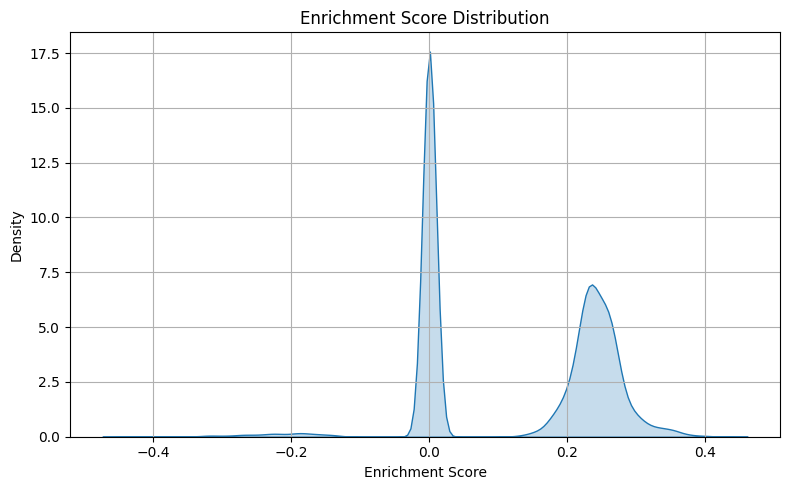

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(cs_result['CS'], fill=True, bw_adjust=0.5)

plt.title("Enrichment Score Distribution")
plt.xlabel("Enrichment Score")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
cs_unique = cs_result.groupby(cs_result.index).min()
reverse_effects = cs_unique[cs_unique['CS'] < 0]
top50 = reverse_effects.sort_values(by='CS').head(50)
top50['Name'] = top50.index

In [29]:
top50.to_csv("top50_pos_mol.csv",sep="\t")

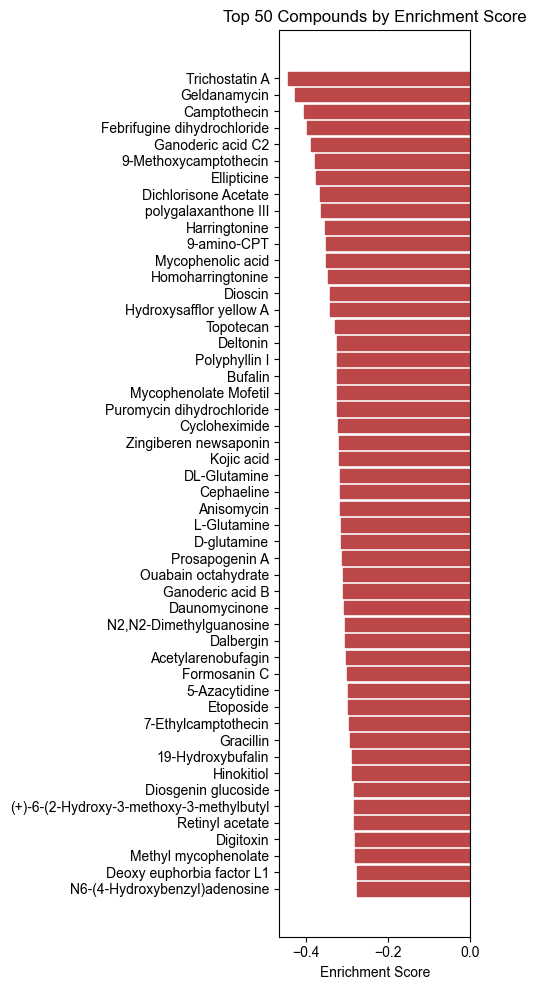

In [37]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

plt.figure(figsize=(5, 10))
bars = plt.barh(top50['Name'], top50['CS'], color='lightgray')
for i in range(len(top50)):
    bars[i].set_color('#bc4749')

plt.xlabel("Enrichment Score")
plt.ylabel("")
plt.title("Top 50 Compounds by Enrichment Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top50_score.raw_expr_v2.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [39]:
cs_unique_vld = cs_unique[cs_unique['CS'] < 0]

In [41]:
cs_unique_vld.to_csv("all_vld_mol.csv")

In [21]:
cs_unique = cs_result.groupby(cs_result.index).min()
reverse_effects = cs_unique[cs_unique['CS'] < 0]
all_pos_mol = reverse_effects.sort_values(by='CS')
all_pos_mol['Name'] = all_pos_mol.index

/tmp/ipykernel_55021/3407033460.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


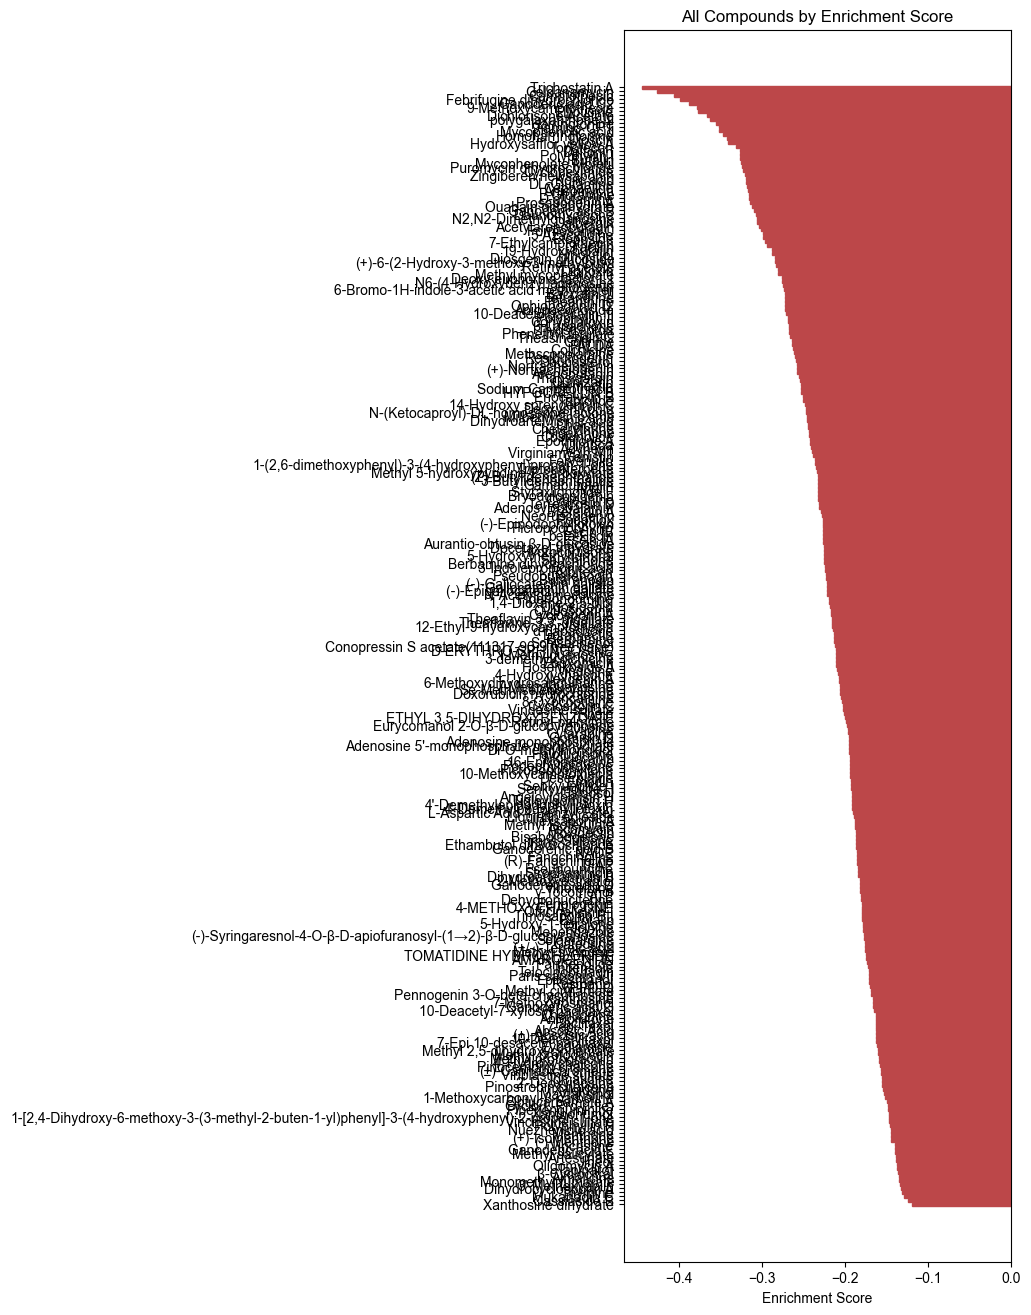

In [26]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

plt.figure(figsize=(5, 16))
bars = plt.barh(all_pos_mol['Name'], all_pos_mol['CS'], color='lightgray')
for i in range(len(all_pos_mol)):
    bars[i].set_color('#bc4749')

plt.xlabel("Enrichment Score")
plt.ylabel("")
plt.title("All Compounds by Enrichment Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("all_pos_mol_score.raw_expr_v2.pdf", format="pdf", bbox_inches="tight")
plt.show()